# **Introduction to Logistic Regression**

In many machine learning tasks, the goal is to predict **a continuous value**, such as house prices or temperature. Methods such as Linear Regression, Ridge Regression, and LASSO Regression are designed for this type of problem.

However, many real-world problems require predicting **a categorical outcome** rather than a continuous value.

**Logistic regression** is a widely used machine learning algorithm designed to address this type of problem. Despite the word *regression* in its name, logistic regression is actually a **classification algorithm**. Its purpose is to predict the probability that an observation belongs to a particular class.





## **Continuous vs. Categorical Targets**

Machine learning problems can generally be divided into two categories based on the type of target variable:

### **Regression Problems**
The target variable is **continuous**.

Examples:
- Predicting house prices
- Predicting temperature
- Predicting stock prices

These problems are commonly solved using **linear regression models**.

### **Classification Problems**
The target variable is **categorical**.

Examples:
- Email: spam or not spam
- Medical diagnosis: disease present or absent
- Image recognition: cat, dog, or bird


Logistic regression models the **probability of belonging to a class**, and then converts that probability into a class prediction.

<br>

Classification problems can involve:

  - **Binary Classification**
    - Two possible classes  
    - Example: 0 = No, 1 = Yes

  - **Multiclass Classification**
    - More than two classes  
    - Example: car, street, bridge

    Logistic regression is most commonly introduced for **binary classification**, though it can be extended to handle multiclass problems.


## **Historical Background**

The **logistic function** (also called the **sigmoid function**) was introduced in the 1830-1850 century by the Belgian mathematician Pierre François Verhulst while studying population growth models.

The function describes systems that grow rapidly at first and then **slow down due to natural limits**, producing an S-shaped curve.

Later, in the 1940s, the logistic function was applied in statistics by Joseph Berkson to model binary outcomes. This work led to the development of what is now known as **logistic regression**.

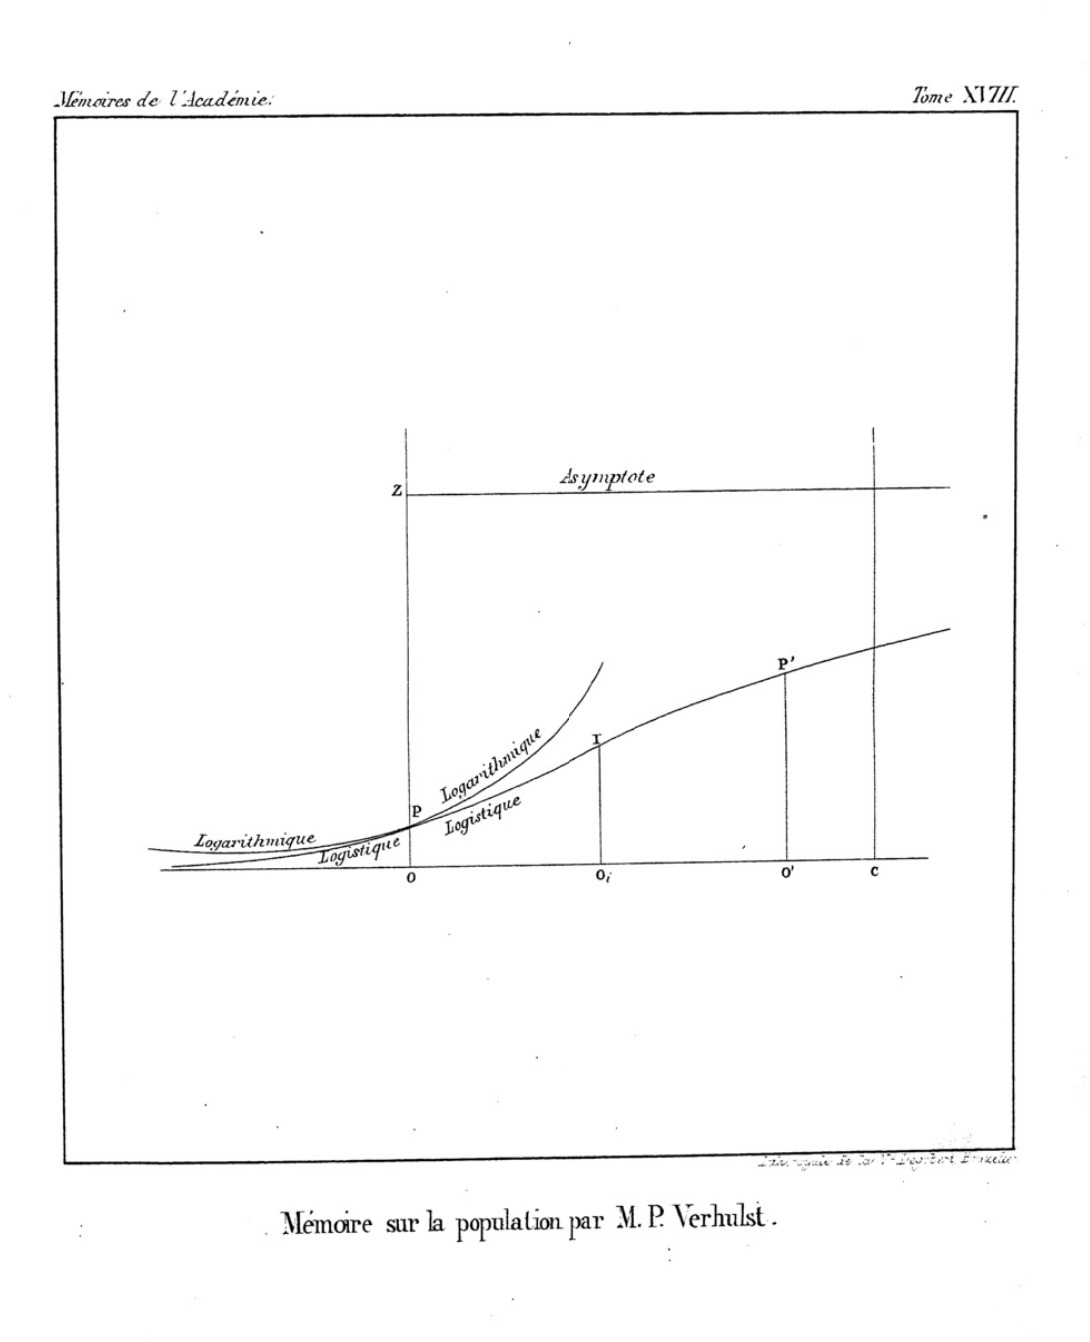

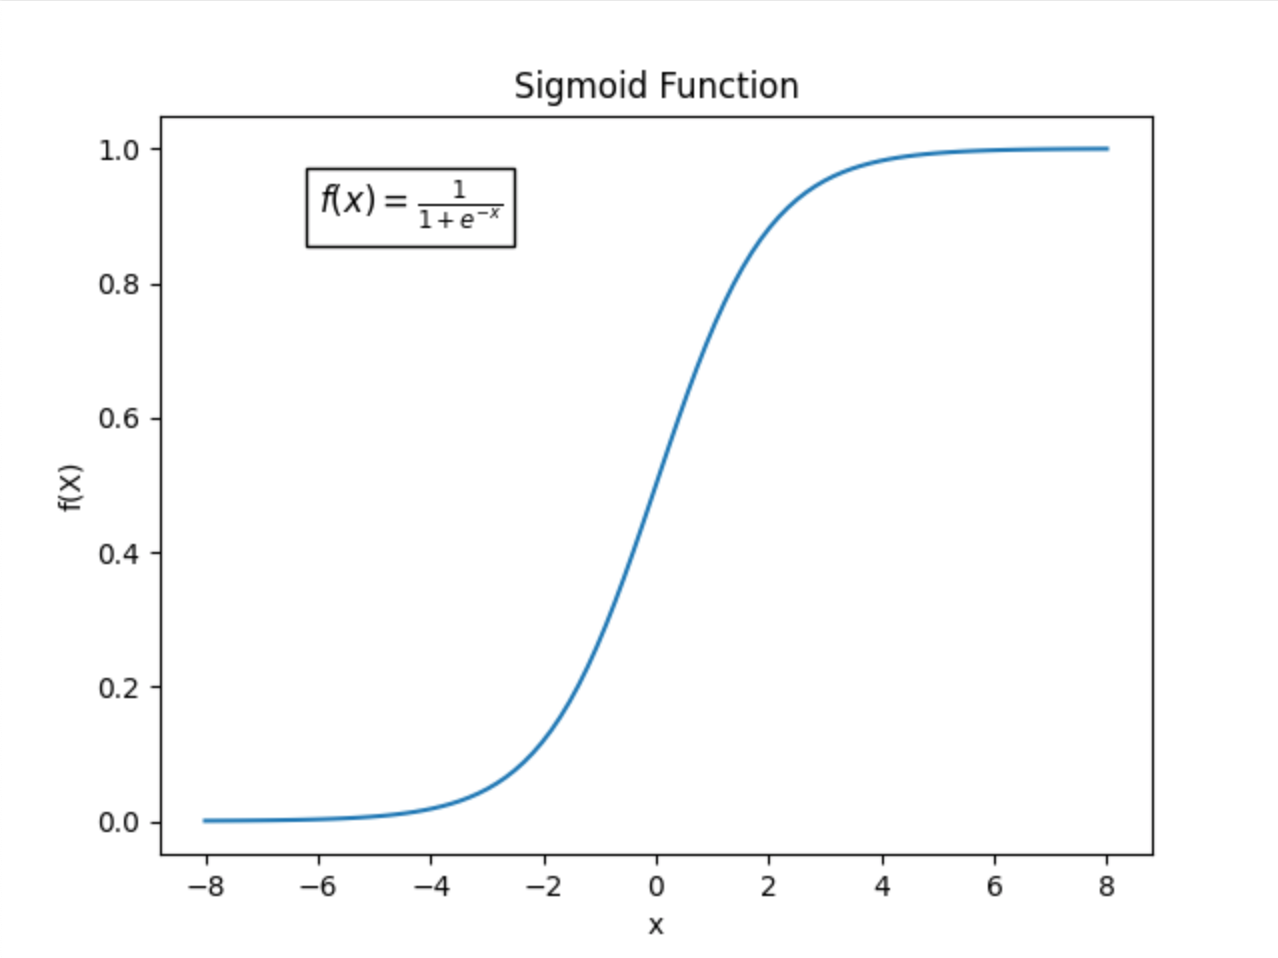



* **Bidirectional Leveling:** The curve distinctly flattens out as it extends toward both ends of the x-axis.

* **Lower Bound (Negative Limits):** As x values go negative, the curve approaches zero.

* **Upper Bound (Positive Limit):** As x values go positive, the curve approaches one.

*  **Confined Output:** Because of these limits, the standard logistic function's output is strictly bounded between 0 and 1



Many natural, real-world systems have a natural limiting factor or **"carrying capacity"** that prevents infinite growth. These systems typically start with exponential growth, but eventually level off as limiting factors slow the growth rate.

e.g. Bacterial Growth in a Petri Dish, Animal Populations in a Habitat, The Spread of a Virus, Technology Adoption, The Spread of a Rumor or Meme, etc.


<br><br>

## **Limitations of Linear Regression for Classification**

One might attempt to apply **linear regression** to a classification problem by encoding class labels numerically (for example, 0 and 1). However, this approach presents several problems.

- **Predictions Are Not Constrained Between 0 and 1**

  Linear regression can produce unbounded values and predictions outside the valid probability range.

  Example: $\hat{y} = 1.4 \quad \text{or} \quad \hat{y} = -0.3$. These values cannot represent probabilities.

- **Poor Interpretation of Intermediate Values**

  A prediction of 0.2 does not clearly correspond to a meaningful class label.


- **Unstable Decision Boundaries**

  Polynomial regression may create **complex curves** that pass through the training points, but this can lead to:

  - **Overfitting**
  - Highly **unstable decision boundaries**
  - Poor **generalization to new data**

  The model may oscillate between classes instead of producing a smooth probability transition.


- **Sensitivity to Outliers**

  Linear regression can be heavily influenced by extreme values, which can distort the decision boundary in classification tasks.

- **Wrong Loss Function**

Because of these issues, linear regression is generally **not suitable for classification problems**.

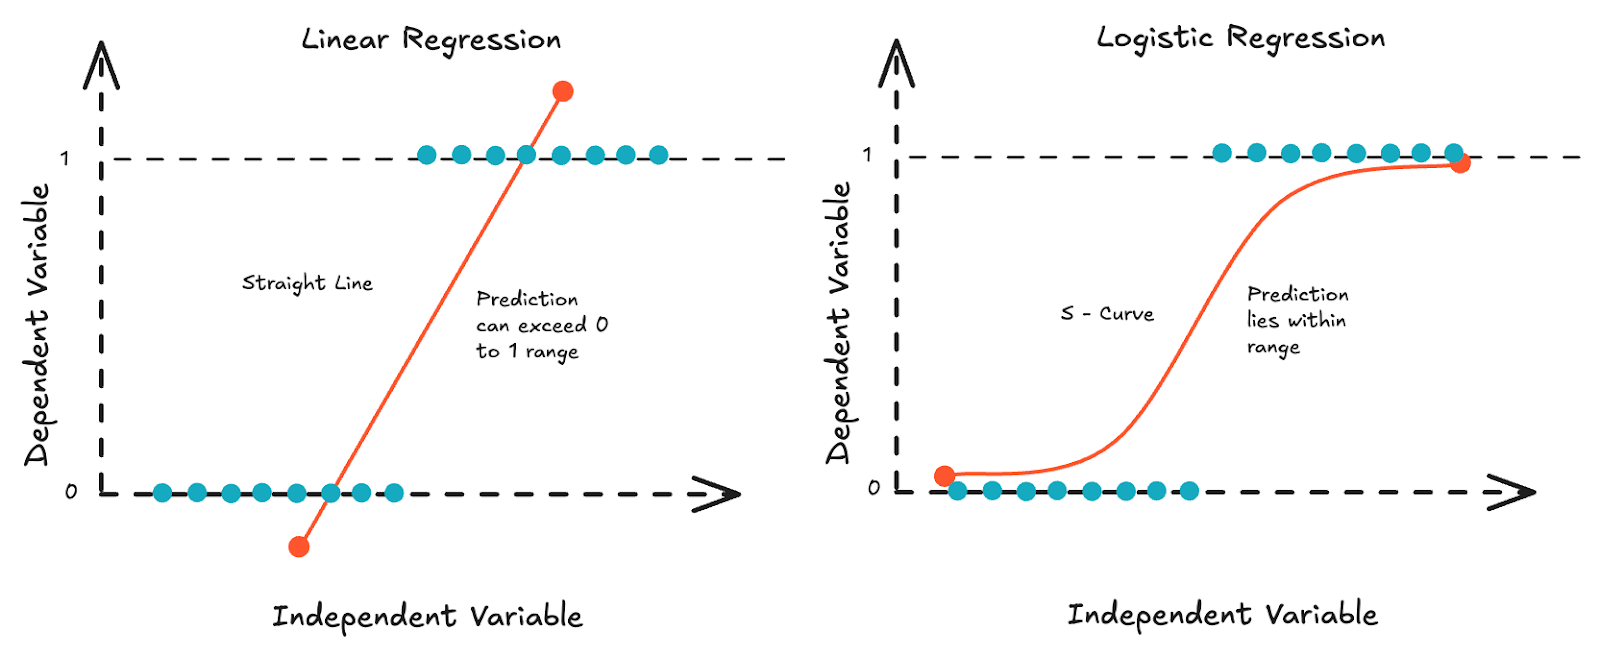

## **The Logistic (Sigmoid) Function**

To address the limitations of linear regression in classification tasks, logistic regression uses the **logistic function**, also known as the **sigmoid function**.

The sigmoid function transforms any real-valued input into a value between **0 and 1**, making it suitable for modeling probabilities.

<br>
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Key properties of the sigmoid function:

- Input range: $ (-\infty, +\infty) $
- Output range: $ (0,1) $
- The output can be interpreted as a **probability**

The function produces an **S-shaped curve**, where:

- Very negative inputs approach **0**
- Very positive inputs approach **1**
- The midpoint occurs at **0.5**

This property allows logistic regression to convert the output of a **linear model** into a **probability estimate**, which can then be used to classify observations into categories.

Basically we consider Y axis as a probability of belonging to a class and using a thershold we determine the class

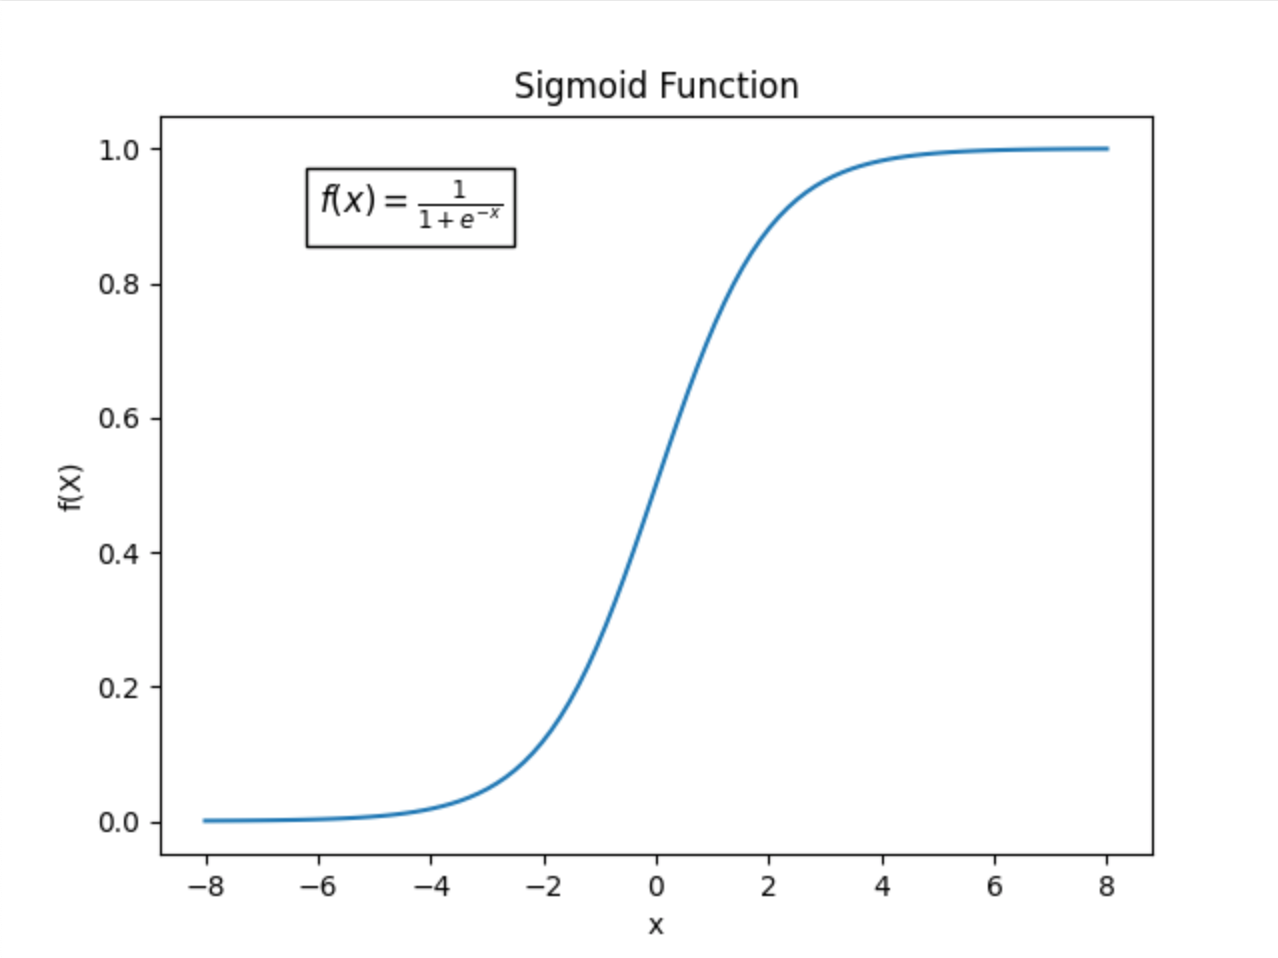

## **From Linear Regression to Logistic Regression**

Logistic regression can be viewed as a modification of linear regression that allows the model to produce **probability outputs** suitable for classification.

Recall the linear regression model:

$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p $$

or in summation notation:

$$\hat{y} = \sum_{j=0}^{p} \beta_j x_j$$

This expression can produce any real number from negative infinity to positive infinity. However, probabilities must lie between **0 and 1**.

To solve this problem, logistic regression passes the linear combination of features through the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

<br>
The resulting logistic regression model becomes:

$$ \hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)}}
$$

<br>

This transformation ensures that the output always lies between **0 and 1**, which allows it to be interpreted as a **probability of belonging to class 1**.

## **Logistic Regression Decision Rule**

The output of logistic regression is a **probability**. To convert this probability into a predicted class label, a **decision threshold** is used.

The most common threshold is **0.5**.

Prediction rule:

$$
\hat{y} =
\begin{cases}
1 & \text{if } P(y=1|x) \geq 0.5 \\
0 & \text{if } P(y=1|x) < 0.5
\end{cases}
$$

Example:

| Predicted Probability | Predicted Class |
|----------------------|----------------|
| 0.82 | 1 |
| 0.67 | 1 |
| 0.41 | 0 |
| 0.12 | 0 |

The threshold does not have to be 0.5. In certain applications, such as **fraud detection or medical diagnosis**, different thresholds may be chosen to balance different types of errors.


<br>

> How logistic regression coefficients are interpreted?
How an increase in one unit could be interpreted versus the coefficient and its effect on y-hat?

## **Odds and Log-Odds (Logit)**

To better understand how logistic regression coefficients are interpreted, it is helpful to introduce the concepts of **odds** and **log-odds**.

- ### **Odds**

  The **odds** of an event are defined as: $ \frac{P}{1-P}$

  where $P$ is the probability of the event occurring.

  So **odds** is the probability of the event occurring over the probability of the event not occurring.

  Example:

  If the probability of an event is **0.75**, the odds are: $\frac{0.75}{1-0.75} = \frac{0.75}{0.25} = 3$

  This can be interpreted as **3 to 1 odds** in favor of the event occurring.

<br>

- ### **Log-Odds (Logit)**

  Logistic regression actually models the **logarithm of the odds**, known as the **logit**: $\log \left(\frac{P}{1-P}\right)$
  
  The key result is: $\log \left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$

How:
<br>
$$ \hat{y} = \frac{1}{1 + e^-{\sum_{i=0}^{n} \beta_i x_i}}$$
<br>
$$ \hat{y} + \hat{y} e^-{\sum_{i=0}^{n} \beta_i x_i} = 1 $$
<br>
$$  \hat{y} e^-{\sum_{i=0}^{n} \beta_i x_i} = 1 - \hat{y} $$
<br>
$$  \frac{\hat{y}}{1-\hat{y}}  = e^{\sum_{i=0}^{n} \beta_i x_i} $$
<br>
$$  ln(\frac{\hat{y}}{1-\hat{y}})  = {\sum_{i=0}^{n} \beta_i x_i} $$
<br>


  This means that logistic regression assumes that the **log-odds of the event are a linear function of the features**.

This transformation allows the model to combine features linearly while still producing valid probabilities between **0 and 1**.



## **Interpretation of Logistic Regression Coefficients**

Because logistic regression models **log-odds**, the coefficients are interpreted differently from linear regression.

### **Sign of the Coefficient**

- **Positive coefficient** → Increasing the feature increases the probability of belonging to class 1.

- **Negative coefficient** → Increasing the feature decreases the probability of belonging to class 1.

### **Magnitude**

Larger magnitude indicates a stronger influence on the prediction.


<br>

### **Odds Ratio**

A more interpretable quantity is the **odds ratio**. For a continuous independent variable the odds ratio can be defined as:
<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/18dc1087bc50b9c1afee6820aad1858704b43ea3" >

Interpretation:

  - $e^{\beta_j} > 1$: increases the odds of class 1
  - $e^{\beta_j} < 1$: decreases the odds of class 1
  - $e^{\beta_j} = 1$: no effect

Example:

If $\beta_1 = 0.7$ then $e^{0.7} \approx 2.01$

This means that **a one-unit increase in $x_1$ multiplies the odds of the event by approximately 2**.





## **Example: Loan Default Prediction**

Consider a model that predicts whether a person will **default on a loan**.

**Features:** Income, Debt, Credit Score

**Target Variable:**
$
y =
\begin{cases}
1 & \text{No Default} \\
0 & \text{Default}
\end{cases}
$

<br>

**Logistic Regression Model:**


$$
P(y=1) =
\frac{1}{1 + e^{-(\beta_0 + \beta_1 \text{Income} + \beta_2 \text{Debt} + \beta_3 \text{CreditScore})}}
$$

where:

- $\beta_0$ is the intercept
- $\beta_1, \beta_2, \beta_3$ are model coefficients
- the features are **Income, Debt, and Credit Score**


**Prediction:**

Suppose the model outputs: $P(y=1) = 0.87$

This means there is an **87% probability that the person will not default** on the loan.

Using a decision threshold of **0.5**, the model predicts: $\hat{y} = 1$


**Interpretation:**

Because the predicted probability is high, the model concludes that **the person is unlikely to default on the loan**.

<br><br>

## **What is the best fit?**

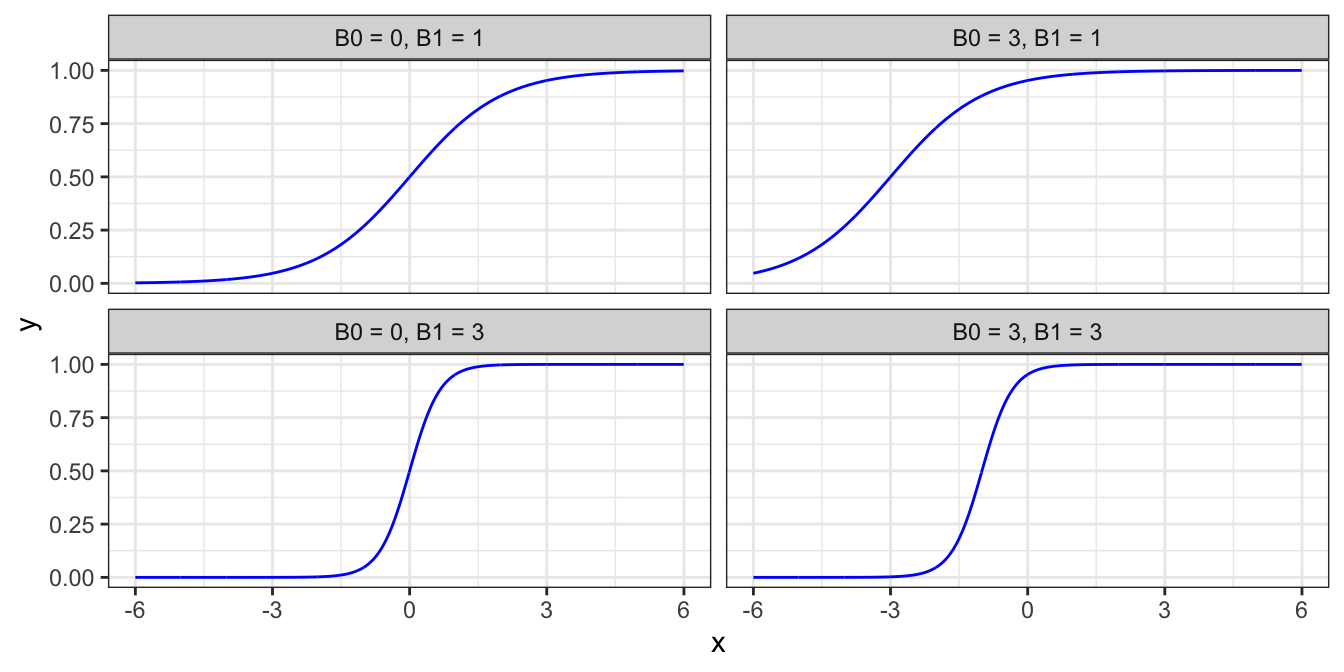

When training a machine learning model, a key question is:

**What is the best set of parameters for our model?**

To answer this, we define a **loss function**, which measures how different the model's predictions are from the true labels.  
Then we use an optimization method such as **gradient descent** to find parameters that **minimize the loss**.


### **Statistical Perspective: Maximum Likelihood**

In statistics, this idea is known as **Maximum Likelihood Estimation (MLE)**.

Logistic regression uses Maximum Likelihood to find the best fitting model.


The principle is simple:

> Choose the parameters that make the **observed data most likely** under the model.


<br>

 **Example with Logistic Regression**

In logistic regression, the model predicts the conditional probability that an observation belongs to class 1:

$$
P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}
$$



This output is always between **0 and 1**, so it can be interpreted as a probability.

For each data point:

- If the true label is **1**, we want the predicted probability to be **large**
- If the true label is **0**, we want the predicted probability to be **small**

**Note:** $P(y=1∣x)$ means: The probability that the label is 1 given the input features  x.

<br>

### **Likelihood Idea**

For a dataset with many observations, we want to choose parameters that make the **overall probability of the observed labels as large as possible**.

Mathematically, this means maximizing the **likelihood**:

$$
L(\beta) = \prod_i P(y_i|x_i)
$$

means:

> We want to choose the parameters β so that the product of the probabilities of all observed labels is as large as possible.

**Note:** In practice, we instead **minimize a loss function** derived from this idea.

<br>

### **Log-Likelihood → Loss Function**

Instead of maximizing the product of probabilities directly, we take the **logarithm** of the likelihood.  
This converts the product into a sum, which is easier to work with mathematically.

$$
\log L(\beta) = \sum_i \log P(y_i \mid x_i)
$$

In machine learning, we usually convert this into a **loss function** by taking the negative value:

$$
Loss = - \sum_i \log P(y_i \mid x_i)
$$

This loss function is known as **cross-entropy loss** (also called **log loss**) and is commonly used when training **logistic regression models**.


In logistic regression, the predicted probability is:

$$
p_i = P(y_i = 1 \mid x_i)
$$

Then the **log-likelihood** can be written as:

$$
\log L(\beta) =
\sum_i
\left[
y_i \log(p_i) + (1 - y_i)\log(1 - p_i)
\right]
$$

This expression automatically handles both possible class labels:

- If $y_i = 1$ → the term becomes $ \log(p_i) $
- If $y_i = 0$ → the term becomes $ \log(1 - p_i) $

So the model is rewarded when it assigns **high probability to the correct class**.

<br>

### **Gradient Descent Finds the Best Parameters**

Once we define a **loss function**, we need a method to find the parameters that minimize it.

This is done using **gradient descent**, an optimization algorithm that iteratively improves the model parameters.

The basic idea is:

1. Start with **random parameters**
2. **Compute the loss** using the training data
3. **Compute the gradient** (the direction that reduces the loss)
4. **Update the parameters**
5. Repeat until the **loss becomes small**



### **Key Idea**

- **Maximum Likelihood** → tells us **what to optimize** (the objective)
- **Gradient Descent** → tells us **how to find the optimal parameters**



<br>

## **Logistic Regression with Scitkit-Learn**

### **Data**

An experiment was conducted on 5000 participants to study the effects of age and physical health on hearing loss, specifically the ability to hear high pitched tones. This data displays the result of the study in which participants were evaluated and scored for physical ability and then had to take an audio test (pass/no pass) which evaluated their ability to hear high frequencies. The age of the user was also noted. Is it possible to build a model that would predict someone's liklihood to hear the high frequency sound based solely on their features (age and physical score)?

* Features

    * age - Age of participant in years
    * physical_score - Score achieved during physical exam

* Label/Target

    * test_result - 0 if no pass, 1 if test passed

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('hearing_test.csv')
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### **Exploratory Data Analysis and Visualization**

Feel free to explore the data further on your own.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [ ]:
df['test_result'].value_counts()

,count
test_result,
1,3000
0,2000


<Axes: xlabel='test_result', ylabel='count'>

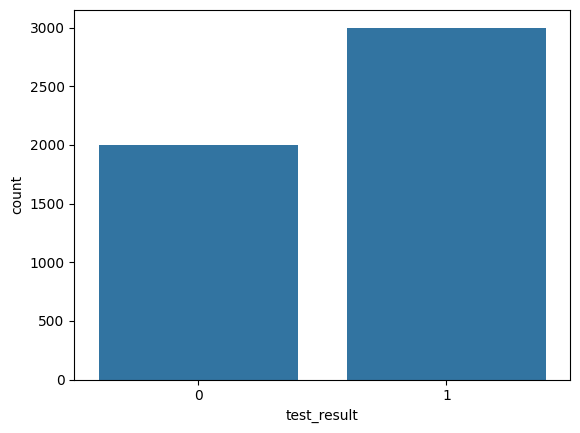

In [ ]:
sns.countplot(data=df,x='test_result')

<Axes: xlabel='physical_score', ylabel='test_result'>

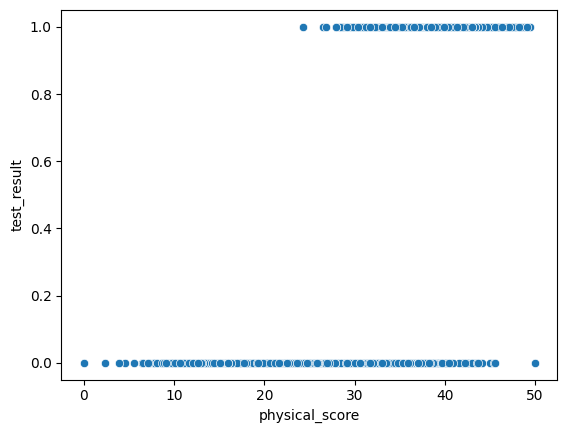

In [ ]:
sns.scatterplot(x='physical_score',y='test_result',data=df)

<Axes: xlabel='age', ylabel='test_result'>

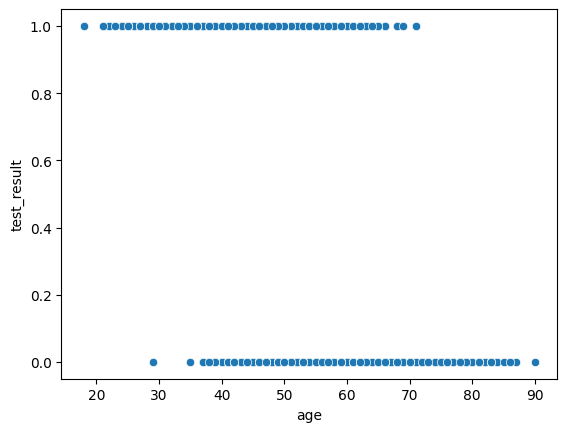

In [ ]:
sns.scatterplot(x='age',y='test_result',data=df)

<Axes: xlabel='test_result', ylabel='age'>

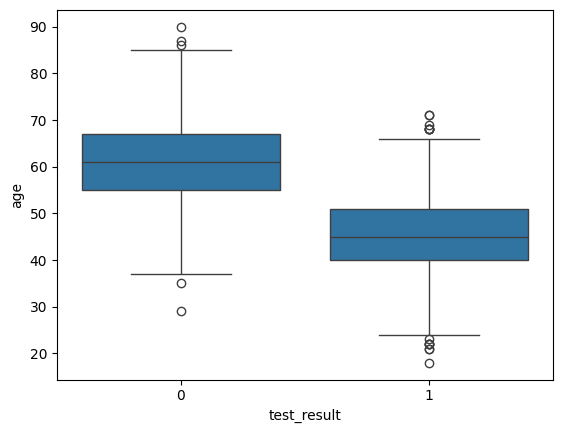

In [ ]:
sns.boxplot(x='test_result',y='age',data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

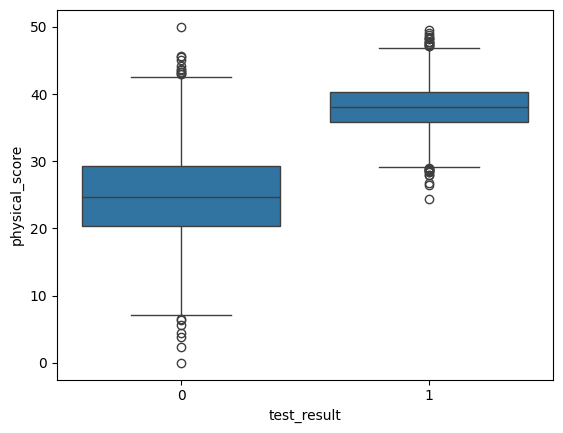

In [ ]:
sns.boxplot(x='test_result',y='physical_score',data=df)

<Axes: xlabel='age', ylabel='physical_score'>

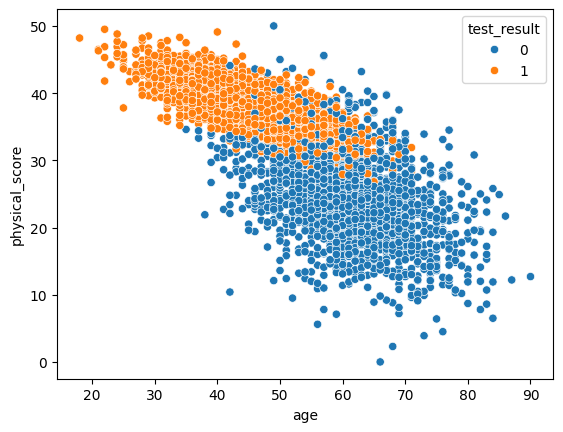

In [ ]:
sns.scatterplot(x='age', y='physical_score', hue='test_result', data=df)

<Axes: >

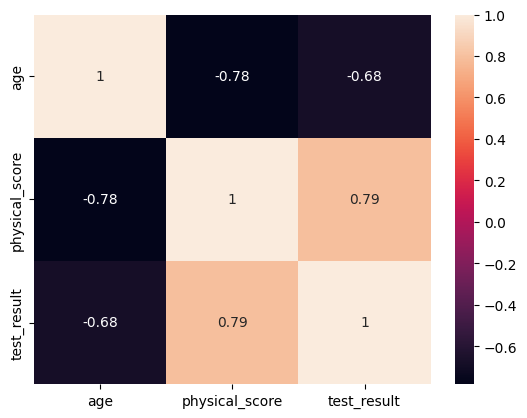

In [ ]:
sns.heatmap(df.corr(),annot=True)

Easily discover new plot types with a google search! Searching for "3d matplotlib scatter plot" quickly takes you to: https://matplotlib.org/3.1.1/gallery/mplot3d/scatter3d.html

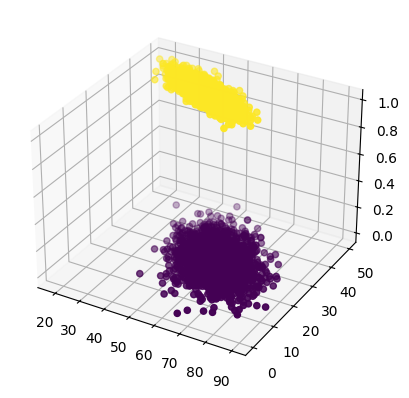

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age'],df['physical_score'],df['test_result'],c=df['test_result'])

### **Train | Test Split and Scaling**

In [ ]:
X = df.drop('test_result',axis=1)
y = df['test_result']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### **Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted
 |  (and copied).
 |
 |  The 'newton-cg', 'sag', and 'lbfgs' solvers support

In [ ]:
log_model = LogisticRegression()
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [ ]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

### **Coefficient Interpretation**

Things to remember:

* These coeffecients relate to the *odds* and can not be directly interpreted as in linear regression.
* We trained on a *scaled* version of the data
* It is much easier to understand and interpret the relationship between the coefficients than it is to interpret the coefficients relationship with the probability of the target/label class.

<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/18dc1087bc50b9c1afee6820aad1858704b43ea3" >

This exponential relationship provides an interpretation for $\beta _{1}$

The odds multiply by ${e^\beta _{1}}$ for every 1-unit increase in x.

This means:
* We can expect the **odds** of passing the test to **decrease** (the original coeff was negative) per unit increase of the age.
* We can expect the **odds** of passing the test to **increase** (the original coeff was positive) per unit increase of the physical score.
* Based on the ratios with each other, the physical_score indicator is a stronger predictor than age.

### **Model Performance on Classification Tasks**

In [ ]:
y_pred = log_model.predict(scaled_X_test)

accuracy_score:  0.93 

confusion_matrix: 
  [[172  21]
 [ 14 293]] 

classification_report: 

                precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500
 



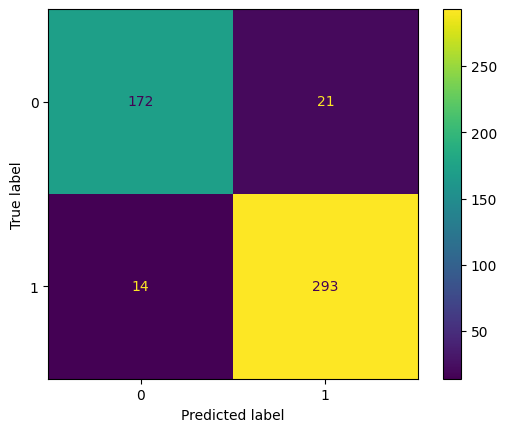

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print('accuracy_score: ', accuracy_score(y_test,y_pred), '\n')
print('confusion_matrix: \n ', confusion_matrix(y_test,y_pred), '\n')
print('classification_report: \n\n ',classification_report(y_test,y_pred), '\n')


cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model.classes_)
display_cm.plot()


### **Evaluating Curves and AUC**


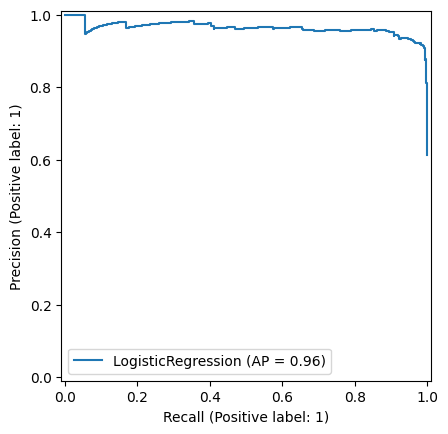

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)

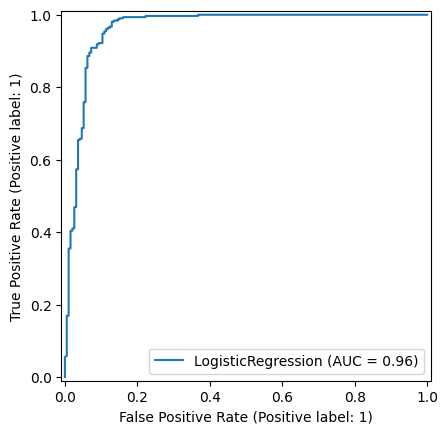

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_model,scaled_X_test,y_test)

In [ ]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_pred)
print(f'AUC Score for ROC Curve: {auc_score}')

AUC Score for ROC Curve: 0.9227945519906837
